# 11 · Verificación Base + LSTM frente a B + LSTM en las estaciones evaluables de 2025

**Objetivo:** comprobar si el resultado de CCA se mantiene entre estaciones, sin seleccionar sólo las favorables a B. Se incluyen las 27 estaciones con modelo guardado y se documentan las otras seis.

Predicciones y p95 **guardados por estación del notebook 09 principal**, sin entrenamiento, nueva inferencia ni ajuste de umbrales. No se usa 22.6 ppb como umbral universal.

La comparación principal cuenta cambios de banda **por lectura** que escapan al detector entre **todos los intentos** sobre posiciones 0…15. La pérdida de lecturas y las falsas alarmas se presentan por separado. No se restringe la conclusión a los ataques aceptados por ambos formatos.

## 1. Protocolo fijado antes de interpretar

- 100 campañas por estación, semillas 42…141; selección independiente de cada lectura válida con probabilidad 5 %.
- N uniforme entre 1 y 16, después posiciones uniformes sin reemplazo. N cuenta bits invertidos en una lectura.
- Base y B reciben exactamente los mismos momentos, N y posiciones dentro de cada estación y campaña.
- CCA conserva su sorteo del 08 para verificar sus resultados. Las demás estaciones utilizan flujos reproducibles separados mediante la semilla y el identificador de estación.
- Misma lectura original y detector; cambian los pesos y las posiciones reservadas. Base es el control de dominio 0…255, no Analog Input estándar sin restricción. Base reserva 8…15 y B reserva 12…15.
- Cada ataque pasa por cifrado/flip/descifrado. Un rechazo implica ausencia de la lectura, sin alerta LSTM evaluable. Una alerta no elimina el dato automáticamente.
- Las entradas, perfiles y predicciones permanecen congelados. No se propagan las alteraciones a ventanas futuras ni a entradas de modelos de otras estaciones.

**Criterio de interpretación:** una mejora del agregado no basta si esconde estaciones que empeoran. Un resultado favorable sólo en una estación debe validarse de forma independiente. No se declaran diferencias estadísticamente significativas basándose sólo en conteos pequeños.

In [1]:
from pathlib import Path
import sys,importlib
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display,Markdown
actual=Path.cwd().resolve()
RAIZ=next(p for p in (actual,*actual.parents) if (p/'experiments/cayenne_mod/campanas_estaciones.py').is_file())
if str(RAIZ) not in sys.path: sys.path.insert(0,str(RAIZ))
from experiments.cayenne_mod import campanas_estaciones as ce
ce=importlib.reload(ce)
# False abre las tablas ya ejecutadas y verifica hashes, sin repetir miles de campañas.
# True reconstruye las 27 estaciones DOS VECES; puede tardar varios minutos.
RECALCULAR=False
if RECALCULAR:
    r,info=ce.construir(RAIZ)
    r2,info2=ce.construir(RAIZ)
    assert info==info2
    for nombre in r: pd.testing.assert_frame_equal(r[nombre],r2[nombre],check_exact=True)
    del r2
    info['reproducibilidad']='Dos ejecuciones completas idénticas de las 27 estaciones y 100 campañas'
    DESTINO=ce.guardar(RAIZ,r,info)
    ce.firmar_tablas(DESTINO)
else:
    r,info,DESTINO=ce.cargar(RAIZ)
print(info['modelo'])
print(info['reproducibilidad'])
print(f"{info['n_estaciones']} estaciones, {info['n_mensajes']} lecturas originales; {len(info['semillas'])} campañas por estación.")
print('Periodo:',info['inicio'],'a',info['fin'])
print(f"Ataques cifrados evaluados, contando ambos formatos: {info['ataques_cifrados_evaluados']:,}.")
print('Resultados de CCA comprobados contra el experimento 08.')

Predicciones y p95 GUARDADOS por estación del notebook 09; sin entrenamiento ni nueva inferencia
Dos ejecuciones completas idénticas de las 27 estaciones y 100 campañas
27 estaciones, 35704 lecturas originales; 100 campañas por estación.
Periodo: 2025-10-21 00:00:00 a 2025-12-31 23:00:00
Ataques cifrados evaluados, contando ambos formatos: 358,798.
Resultados de CCA comprobados contra el experimento 08.


## 2. Cobertura: no todas las estaciones aportan la misma evidencia

«Mensajes» y «días observados» son datos originales, antes de repetir campañas. Repetir 100 veces una estación con pocas lecturas no crea otras concentraciones ni otros periodos de prueba.

Los faltantes del raw no se atacan. Para las estaciones evaluables se verifica que todas las lecturas observadas del periodo coincidan con las usadas para evaluación. No se rellenan huecos con cero.

La tabla de excluidas indica por qué no existe detector evaluable. No suponemos que el ataque se detectaría en esas estaciones.

In [2]:
display(r['limpios'].round(3))
display(Markdown('**Estaciones sin modelo evaluable en esta referencia:**'))
display(r['cobertura'].loc[~r['cobertura'].evaluable].reset_index(drop=True))

,estacion,mensajes,dias_observados,umbral_ppb,maximo_limpio,falsas_alarmas,fpr_limpio_pct
0,ACO,59,3,13.773,44.0,4,6.780
1,AJM,1671,72,22.158,145.0,242,14.482
2,ATI,1681,71,26.958,126.0,61,3.629
3,BJU,478,21,20.660,107.0,80,16.736
4,CAM,1656,72,17.370,144.0,213,12.862
5,CCA,1684,72,14.748,145.0,360,21.378
6,CUA,1553,67,29.444,136.0,73,4.701
7,CUT,1604,69,15.628,113.0,227,14.152
8,FAC,1004,44,16.846,111.0,177,17.629
9,GAM,561,25,19.226,102.0,126,22.460


**Estaciones sin modelo evaluable en esta referencia:**

,estacion,n_train,n_test,evaluable,motivo
0,AJU,2398,0,False,sin ventanas de prueba
1,CHO,2984,0,False,sin ventanas de prueba
2,FAR,6210,0,False,sin ventanas de prueba
3,IZT,4638,0,False,sin ventanas de prueba
4,MON,5277,0,False,sin ventanas de prueba
5,TAH,5560,0,False,sin ventanas de prueba


## 3. Comparación por estación: resultado principal

Cada fila suma las 100 campañas de esa estación. «Escapes» significa lecturas aceptadas que cambian de banda sin alerta. «Diferencia» es B menos Base: negativa favorece B en ese conteo; positiva favorece Base.

Las tasas usan como denominador **todos los intentos de ataque de esa estación**, incluidos los rechazados; los rechazos se examinan como costo en la sección siguiente. Las diferencias en puntos porcentuales permiten comparar estaciones con distinta cantidad de observaciones.

«Menos», «igual» y «más» describen las campañas pareadas, no una prueba estadística de superioridad.

,estacion,intentos,escapes_base,escapes_B,diferencia,tasa_base,tasa_B,diferencia_pp,semillas_menos,semillas_igual,semillas_mas
0,ACO,254,0,0,0,0.0000,0.0000,0.0000,0,100,0
1,MGH,6906,11,13,2,0.1593,0.1882,0.0290,5,89,6
2,LPR,8200,8,12,4,0.0976,0.1463,0.0488,1,94,5
3,INN,7859,6,11,5,0.0763,0.1400,0.0636,3,89,8
4,CCA,8377,13,19,6,0.1552,0.2268,0.0716,8,81,11
5,BJU,2458,4,6,2,0.1627,0.2441,0.0814,0,98,2
6,LLA,7844,8,15,7,0.1020,0.1912,0.0892,4,85,11
7,SAC,7143,15,23,8,0.2100,0.3220,0.1120,5,83,12
8,HGM,8489,7,17,10,0.0825,0.2003,0.1178,1,89,10
9,SAG,7509,4,13,9,0.0533,0.1731,0.1199,2,87,11


B tiene menos escapes acumulados en 0 estaciones, igual cantidad en 1 y más en 26.


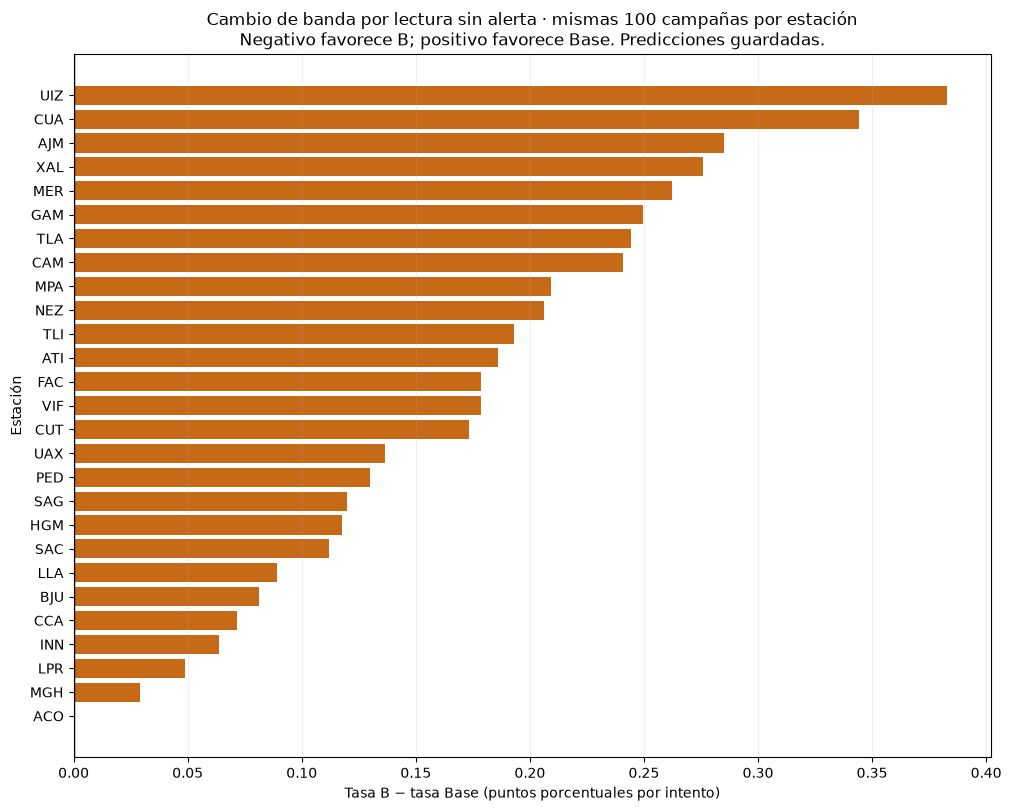

In [3]:
p=r['pareados'].sort_values('diferencia_pp')
display(p.round(4).reset_index(drop=True))
print(f"B tiene menos escapes acumulados en {(p.diferencia<0).sum()} estaciones, igual cantidad en {(p.diferencia==0).sum()} y más en {(p.diferencia>0).sum()}.")
ce.graficar(r,DESTINO)
plt.show()

## 4. Agregados y costos: dos maneras de ponderar

**Micro:** sumar eventos y oportunidades de todas las estaciones. Las estaciones con más intentos tienen más peso.

**Macro:** promediar las tasas por estación, dando el mismo peso a cada una. Esto también da el mismo peso a estaciones con muy pocos datos; se debe leer junto a la cobertura.

Ninguna de estas agregaciones calcula el máximo de toda la red ni representa una declaración de contingencia. Son resúmenes de las evaluaciones individuales.

In [4]:
cols=['formato','ataques','rechazos','aceptados_atacados','cancelaciones','alterados',
      'detectados_alterados','banda_local_sin_alerta','escape_por_intento_pct','rechazo_pct']
display(Markdown('**Micro: conteos acumulados y tasas sobre todos los intentos**'))
display(r['micro'][cols].round(4))
display(Markdown('**Macro: promedio de tasas de las 27 estaciones (%)**'))
display(r['macro'].round(4))
display(Markdown('**Falsas alarmas sobre lecturas no atacadas, acumuladas**'))
display(r['micro'][['formato','limpios','falsas_alarmas_limpios']])
print('Las falsas alarmas sobre lecturas no atacadas deben coincidir: el detector y los datos limpios son idénticos.')

**Micro: conteos acumulados y tasas sobre todos los intentos**

,formato,ataques,rechazos,aceptados_atacados,cancelaciones,alterados,detectados_alterados,banda_local_sin_alerta,escape_por_intento_pct,rechazo_pct
0,B,179399,152683,26716,544,26172,15623,567,0.3161,85.1081
1,base,179399,169599,9800,0,9800,6094,255,0.1421,94.5373


**Macro: promedio de tasas de las 27 estaciones (%)**

,formato,escape_por_intento_pct,rechazo_pct,fpr_limpios_pct
0,B,0.3122,85.1109,15.742
1,base,0.1414,94.5453,15.742


**Falsas alarmas sobre lecturas no atacadas, acumuladas**

,formato,limpios,falsas_alarmas_limpios
0,B,3391001,535814
1,base,3391001,535814


Las falsas alarmas sobre lecturas no atacadas deben coincidir: el detector y los datos limpios son idénticos.


## 5. Máximos diarios de cada estación y falsas excedencias

Los ataques de una misma fecha se aplican juntos. Se cuenta un día-estación-campaña, no una fecha independiente. Las estaciones sin lecturas en una fecha no aportan una decisión para esa fecha.

- **Días con banda distinta:** daño observado, aunque exista alerta.
- **Sin alerta en alterados:** ninguna lectura cuyo valor cambió generó alerta; puede haber daño por rechazo y falsas alarmas en otras lecturas.
- **Persiste sólo con silenciosos:** diagnóstico que restaura los originales de detectados y rechazados, dejando sólo alteraciones aceptadas sin alerta. No es una corrección disponible al receptor.

Estas medidas se solapan y no se suman. Las alertas no eliminan automáticamente lecturas. El cruce de 155 ppb es una excedencia del máximo observado por estación, no una activación oficial de contingencia.

In [5]:
cols=['formato','dias_banda','dias_banda_sin_alerta_alterados','dias_banda_persiste_silenciosos',
      'dias_falsa_excedencia','dias_falsa_excedencia_sin_alerta_alterados',
      'dias_falsa_excedencia_persiste_silenciosos','dias_sin_datos']
display(r['micro'][cols])
print(f"Máximo limpio entre las estaciones evaluables: {info['maximo_limpio']:.0f} ppb.")
print('Ocultamiento de excedencias originales evaluable:',info['ocultamiento_evaluable'])
print('Sin originales ≥155, los ceros en ocultamiento no acreditan protección.')

,formato,dias_banda,dias_banda_sin_alerta_alterados,dias_banda_persiste_silenciosos,dias_falsa_excedencia,dias_falsa_excedencia_sin_alerta_alterados,dias_falsa_excedencia_persiste_silenciosos,dias_sin_datos
0,B,9106,872,150,4050,1,1,0
1,base,3827,958,71,1176,0,0,0


Máximo limpio entre las estaciones evaluables: 152 ppb.
Ocultamiento de excedencias originales evaluable: False
Sin originales ≥155, los ceros en ocultamiento no acreditan protección.


## 6. Auditoría y límites

Se verifican hashes de modelos, predicciones y fuentes, correspondencia con el raw, transformaciones cifradas y reproducción exacta de CCA. El pipeline completo de las 27 estaciones se ejecutó dos veces y produjo tablas idénticas.

`plan.csv.gz` conserva el ataque elegido para cada estación, semilla y lectura; `ataques.csv.gz` contiene su efecto en cada formato. `diario.csv.gz` permite examinar cada fecha. `por_n.csv` separa los presupuestos y `por_semilla.csv` conserva el pareado. El notebook lee resúmenes verificados por defecto; activar `RECALCULAR` reconstruye todo.

Estos resultados siguen limitados al periodo guardado de 2025 y a la selección aleatoria uniforme de N y posiciones. Las estaciones comparten condiciones ambientales y los sorteos reutilizan las mismas lecturas; no son observaciones independientes de otros años. El atacante dirigido y la contaminación de predicciones futuras no se simulan.

La conclusión debe considerar el agregado, la distribución entre estaciones y los costos. Una estación favorable aislada no rescata automáticamente la propuesta, y un empate con pocos eventos no demuestra equivalencia.

## 7. Dictamen de la verificación

**La ampliación no muestra una mejora general de B: ninguna estación tiene menos escapes acumulados, 26 tienen más y una empata en cero.** ACO, la estación empatada, sólo aporta 59 lecturas originales; no se interpreta su cero como equivalencia demostrada.

En los mismos 179 399 intentos por formato, Base registra **255 cambios de banda por lectura sin alerta** y B **567**. La tasa pasa de **0.1421 % a 0.3161 %**. Dar el mismo peso a las estaciones tampoco cambia la dirección del resultado: **0.1414 % frente a 0.3122 %**.

B pierde 16 916 lecturas menos por rechazo, pero no reduce el daño que escapa al LSTM. Las falsas alarmas sobre lecturas no atacadas son idénticas. El patrón desfavorable se observa por estación y en ambos agregados; no se declara significación estadística de cada diferencia individual.

**Recomendación:** conservar B como resultado negativo documentado para este escenario y dejar de priorizarla como mejora general. La evaluación aporta evidencia para esa decisión sin modificar modelos ni elegir estaciones favorables. No demuestra inutilidad de cualquier redistribución ni protección frente a otros modelos de ataque.

Sigue pendiente un periodo con excedencias originales suficientes para evaluar ocultamiento: el máximo limpio de este test ampliado es 152 ppb. Validar el detector en otros años y estudiar la propagación a entradas futuras son preguntas separadas.

[Resumen para la junta](avance_junta_11.md).